# Set up and download - Molecular cartography data from Legnini et al., 2023 

This tutorials shows how to set up an multiple slide molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Download the sample data from the original publication from [Zenodo](https://doi.org/10.5281/zenodo.6143560) under the accession no. 6143561

In [6]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse, csr_matrix
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

## Load data

In [5]:
adata = sc.read_h5ad(LRZ_LEGNINI23)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [26]:
print('Zero count cells: ', (adata.X.sum(1) ==0).sum())

Zero count cells:  648


## 1. Normalization

The data needs to be normalized for InterScale (Ideally, counts should be normalized between 0 to 3). Check if the data is already normalized: 

In [21]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["raw"] = adata.X
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

Min count: 0.0, Max count: 98518.4583556652


In [30]:
# Freeman-Tukey square root transform
assert issparse(adata.X)
sqrt_X = adata.X.sqrt()
# Create a new sparse matrix for X + 1
X_plus_1 = adata.X + csr_matrix(np.ones(adata.X.shape))
# Calculate the square root of (X + 1)
sqrt_X_plus_1 = X_plus_1.sqrt()
adata.layers['norm_ftsqrt'] = sqrt_X + sqrt_X_plus_1

In [31]:
# shifted Logarithm
scales_counts = sc.pp.normalize_total(adata, target_sum=10000, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

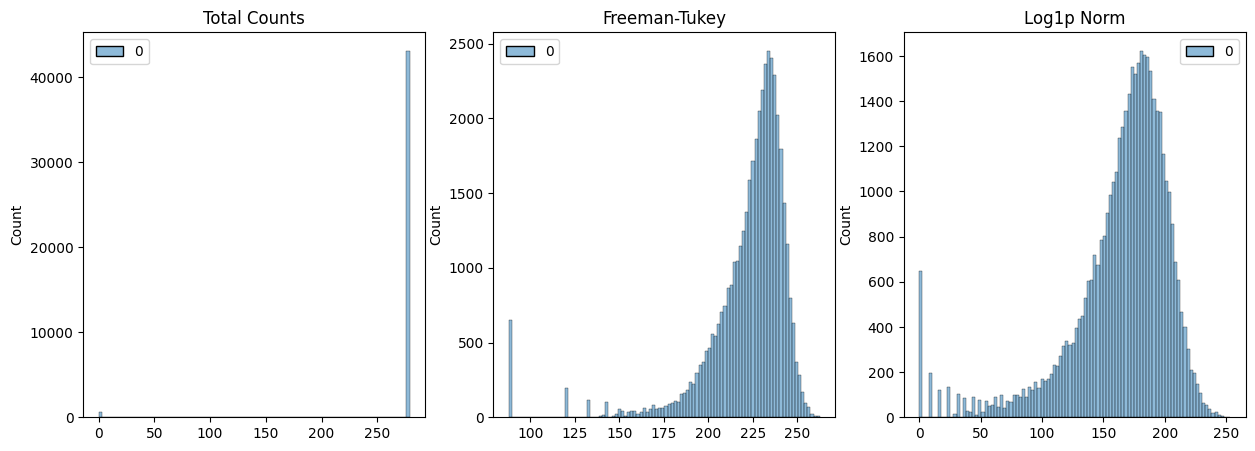

In [32]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p0 = sns.histplot(adata.layers["raw"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total Counts")
p1 = sns.histplot(adata.layers["norm_ftsqrt"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Freeman-Tukey")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("Log1p Norm")
plt.show()

In [33]:
print('Raw - Min: ', {adata.layers['raw'].min()}, ', Max: ', {adata.layers['raw'].max()})
print('Log1pNorm - Min: ', {adata.layers['log1p_norm'].min()}, ', Max: ', {adata.layers['log1p_norm'].max()})
print('NormTRSqrt - Min: ', {adata.layers['norm_ftsqrt'].min()}, ', Max: ', {adata.layers['norm_ftsqrt'].max()})

Raw - Min:  {0.0} , Max:  {279.0}
Log1pNorm - Min:  {0.0} , Max:  {9.210441}
NormTRSqrt - Min:  {1.0} , Max:  {33.4364933773612}


## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For image-based ST it is important to set `coord_type='generic'`. In Squidpy, you have the option between k-nearest neighbors, delaunay and radius based neighborhood. For InterScale, we use a `radius`-based neighborhood to capture density information. Find the radius for which the number of connected neighbors is approximately 10-30, depending on tissue density. 

In [35]:
for radi in [0, 200, 300]:
    print('Radius ', radi)
    sq.gr.spatial_neighbors(
        adata,
        radius=radi,
        coord_type='generic',
        library_key = 'sample'
    )
    conn = adata.obsp['spatial_connectivities']
    # Print average number of connections per node
    avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
    print(f"Average number of connections per node: {avg_connections:.2f}")

Radius  0
Average number of connections per node: 0.00
Radius  200
Average number of connections per node: 10.14
Radius  300
Average number of connections per node: 23.13


In [38]:
#np.isnan(adata.obsm["spatial"]).sum()

Remove all cells that have entry NaN in .obsm['coordinates'].
If NaN is in .obsm it leads to error when creating graph. 

In [39]:
# Create a boolean mask for rows without NaN coordinates
valid_coords = ~np.isnan(adata.obsm["spatial"]).any(axis=1)

# Filter the AnnData object
adata = adata[valid_coords].copy()

# Verify the removal of NaN values
print(f"NaN values remaining: {np.isnan(adata.obsm['spatial']).sum()}")

NaN values remaining: 0


Make sure that obs_names are unique and convertable to string. 

In [40]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    uns: 'spatial_neighbors'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'
    obsp: 'spatial_connectivities', 'spatial_distances'>

In [41]:
adata.obs['obs_names'] = adata.obs_names

In [ ]:
sq.gr.spatial_neighbors(
    adata,
    coord_type = "generic",
    library_key = "ImageNumber",
    radius = 30,
)

In [ ]:
# Calculate nr. of neighbors per cells
conn = adata_pancreas.obsp['spatial_connectivities']
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

In [ ]:
sq.pl.spatial_scatter(
            adata_pancreas,
            color = ['CellCat','CellType'],
            spatial_key = 'spatial',
            library_key='image_name',
            library_id=['M25'],
            shape= None,
            size=50
)

In [ ]:
sq.pl.spatial_scatter(
            adata_pancreas,
            color = ['CellCat','CellType'],
            spatial_key = 'spatial',
            library_key='image_name',
            library_id=['M25'],
            shape= None,
            connectivity_key="spatial_connectivities",
            size=50
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [ ]:
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Select images that have more than some MAX number of cells.

In [ ]:
MAX_CELLS = 2500
tissue_cell_number = adata_pancreas.obs.groupby('ImageNumber').size()
batches_high_nr_cells = tissue_cell_number[tissue_cell_number > MAX_CELLS]
print(batches_high_nr_cells)

We observe that there are a slides with only a few cells but 2 slides with more than 4k cells. For this case we have the option to 1) increase the context length to max = 4875 or 2) calculate sliding windows for all slides that have more than 3k cells. 

In [ ]:
# Use the index of batches_high_nr_cells to get the image numbers
sub_adata = adata_pancreas[adata_pancreas.obs['ImageNumber'].isin(batches_high_nr_cells.index)]
sub_adata

In [ ]:
print(f"Nr cells per for large images: Min: {batches_high_nr_cells.min()}, Max: {batches_high_nr_cells.max()}, Avg: {batches_high_nr_cells.mean()}")

In [ ]:
sq.tl.sliding_window(
    adata=sub_adata,
    library_key="ImageNumber",  # to stratify by sample
    window_size=600,
    overlap=0,
    copy=False,  # we modify in place
)

In [ ]:
window_size = sub_adata.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

In [ ]:
sub_adata.obs["ImageNumber"]

With the sliding windows the maximum number of cells per sliding window is `2418`. 

<mark>TODO: Adjust max_seq_len in config file!</mark>
Given this we adjust the `max_seq_len` from the model.global_component to `2418`. The default is `2000`.

In [ ]:
del sub_adata.uns['sliding_window_assignment_colors']

In [ ]:
sq.pl.spatial_scatter(
    sub_adata[sub_adata.obs['ImageNumber'].isin([839, 6])],
    spatial_key = 'spatial',
    library_key='ImageNumber', 
    #library_id = [839, 6],
    color="sliding_window_assignment", #cell_type_coarse",
    shape= None,
    size = 10,
)

Add sliding window assignments to full dataset.

In [ ]:
max_image_number = adata_pancreas.obs['ImageNumber'].astype(int).max()

# Renumber sliding_window_assignments in sub_adata starting from max_image_number + 1
unique_assignments = sub_adata.obs['sliding_window_assignment'].unique()
assignment_mapping = {old: new for old, new in zip(
    sorted(unique_assignments), 
    range(max_image_number + 1, max_image_number + 1 + len(unique_assignments))
)}

# Create a renumbered version
sub_adata.obs['sliding_window_assignment_renumbered'] = sub_adata.obs['sliding_window_assignment'].map(assignment_mapping)

# Initialize with ImageNumber
adata_pancreas.obs['sliding_window_assignment'] = adata_pancreas.obs['ImageNumber'].astype(int).copy()
mask = adata_pancreas.obs['ImageNumber'].isin(batches_high_nr_cells.index)
adata_pancreas.obs.loc[mask, 'sliding_window_assignment'] = sub_adata.obs['sliding_window_assignment_renumbered'].values

In [ ]:
window_size = adata_pancreas.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

## 4. Split data into train and val set

Training the model requires a `split` assignment for each donor/patient/sliding window that you wanna train on. 

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df = adata_pancreas.obs[['case', 'stage']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

In [ ]:
adata_pancreas.obs['split'] = 'train'
# assign each one [Long-duration, ND, Onset]
adata_pancreas.obs['split'][adata_pancreas.obs['case'].isin([6418, 6126, 6228])] = 'val'
adata_pancreas.obs['split'][adata_pancreas.obs['case'].isin([6089, 6386, 6380])] = 'test'

In [ ]:
df = adata_pancreas.obs[['split', 'case', 'stage']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

## Save adata object

Save the prepared adata object such that it can be loaded for the model training. 

In [ ]:
adata_pancreas.write(f'{BASE_DIR_PROJECT}/data/{DATA}_pp.h5ad')

## Prepare config file

Duplicate the minum requirement config file from `/GT-long-range-niches/src/config_files/InterScale_example.yaml` and add the necessary specification for the Visum data:

```
model:
  local_component:
    name: GCN
  global_component:
    name: self-attn-transformer
        max_seq_len: 2418
  save: /path/to/save/model/
dataset:
  h5ad_data: legnini22.h5ad
  name: Visium_legnini23
  sample_key: ['case']
  spatial_neigbors_kwargs:
    coord_type: grid
    library_key: sliding_window_assignment
```


Save the config file as `.yaml` and proceed to training (either interactively in jupyter notebook or by running a script).